# Model-Predictive Control with Predictive Sampling

KinDER environments expose `get_state`, `set_state`, and `get_transition`
methods that let you simulate the environment without committing to actions.
This makes them suitable for model-based planning techniques.

This notebook demonstrates **predictive-sampling MPC** using the
`kinder_trajopt` library. We first walk through the components —
the trajectory optimization problem, solver, and MPC wrapper — then
show how `TrajOptAgent` packages everything into a single interface.

## Installation

```bash
pip install kindergarden[kinematic2d]
git clone https://github.com/Princeton-Robot-Planning-and-Learning/kinder-baselines.git
cd kinder-baselines
pip install -e kinder-mbrl
pip install -e kinder-trajopt
```

In [1]:
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image
from PIL import Image as PILImage

import kinder
from prpl_utils.trajopt.mpc_wrapper import MPCWrapper
from prpl_utils.trajopt.predictive_sampling import (
    PredictiveSamplingHyperparameters,
    PredictiveSamplingSolver,
)

from kinder_trajopt.agent import TrajOptAgent
from kinder_trajopt.trajopt_problem import KinderTrajOptProblem

## Setup

We use `Motion2D-p0` (no obstacles) so the task is pure navigation to a goal
region. Two environments are created: one for the agent's internal simulation
(`sim_env`, with `allow_state_access=True`) and one for evaluation and
rendering (`eval_env`).

Observation shape: (19,)
Action shape:      (5,)


pybullet build time: Mar 13 2026 19:11:34


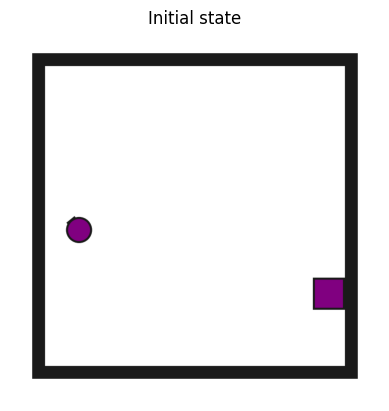

In [2]:
kinder.register_all_environments()

eval_env = kinder.make("kinder/Motion2D-p0-v0", render_mode="rgb_array")
sim_env = kinder.make("kinder/Motion2D-p0-v0", allow_state_access=True)

print("Observation shape:", eval_env.observation_space.shape)
print("Action shape:     ", eval_env.action_space.shape)

obs, info = eval_env.reset(seed=42)
plt.imshow(eval_env.render())
plt.axis("off")
plt.title("Initial state")
plt.show()

## Trajectory Optimization Problem

`KinderTrajOptProblem` wraps a KinDER environment as a trajectory
optimization problem. It uses `get_transition` for deterministic forward
simulation and caches rewards so that trajectory costs can be computed
without re-simulating.

In [3]:
problem = KinderTrajOptProblem(
    env=sim_env,
    initial_state=obs,
    horizon=100,
)

print("State space:", problem.state_space)
print("Action space:", problem.action_space)
print("Horizon:", problem.horizon)

State space: Box(-inf, inf, (19,), float32)
Action space: Box([-0.05       -0.05       -0.19634955 -0.1         0.        ], [0.05       0.05       0.19634955 0.1        1.        ], (5,), float32)
Horizon: 100


## Forward Simulation

We can simulate a single step using `get_next_state`. The problem
caches the reward and termination flag from each call.

In [4]:
action = sim_env.action_space.sample()
next_state = problem.get_next_state(obs, action)

print("Current state (first 5):", obs[:5])
print("Action:                 ", action)
print("Next state (first 5):   ", next_state[:5])

Current state (first 5): [0.2886978 1.133869  2.253137  0.1       0.1      ]
Action:                  [ 0.03467577  0.03187211 -0.13577533 -0.03221405  0.03916227]
Next state (first 5):    [0.3233736 1.1657412 2.1173618 0.1       0.1      ]


## Predictive Sampling Solver

The solver samples candidate trajectories parameterized by spline control
points, evaluates each one via the problem's forward model, and returns the
best trajectory. With `warm_start=True`, previous solutions seed the next
planning step.

In [5]:
action_range = sim_env.action_space.high - sim_env.action_space.low
config = PredictiveSamplingHyperparameters(
    num_rollouts=5,
    noise_scale=action_range * 1.0,
    num_control_points=5,
)
solver = PredictiveSamplingSolver(seed=42, config=config, warm_start=True)

print("Num rollouts:     ", config.num_rollouts)
print("Num control points:", config.num_control_points)
print("Noise scale:      ", config.noise_scale[:3], "...")

Num rollouts:      5
Num control points: 5
Noise scale:       [0.1       0.1       0.3926991] ...


## MPC Wrapper

`MPCWrapper` ties the solver and problem together in a receding-horizon loop.
At each call to `step()`, it re-solves the trajectory optimization problem
from the current state and returns the first action.

In [6]:
mpc = MPCWrapper(solver, replan_interval=1)
mpc.reset(problem)

## Running MPC Manually

We can now run the MPC loop step by step: query the wrapper for an action,
execute it in the evaluation environment, and feed the new observation back.

Reached goal in 40 steps!


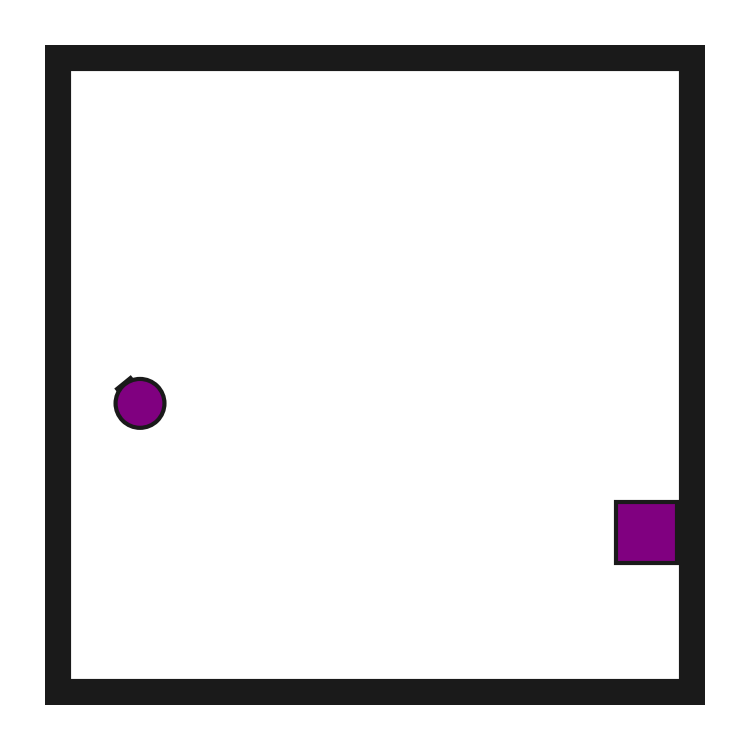

In [7]:
max_steps = 200

obs, info = eval_env.reset(seed=42)
problem = KinderTrajOptProblem(env=sim_env, initial_state=obs, horizon=100)
mpc.reset(problem)
frames = [eval_env.render()]

for step in range(max_steps):
    action = mpc.step(obs)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    frames.append(eval_env.render())

    if terminated:
        print(f"Reached goal in {step + 1} steps!")
        break
else:
    print(f"Did not reach goal within {max_steps} steps.")

pil_frames = [PILImage.fromarray(f) for f in frames]
buf = BytesIO()
pil_frames[0].save(
    buf,
    format="GIF",
    save_all=True,
    append_images=pil_frames[1:],
    duration=100,
    loop=0,
)
Image(data=buf.getvalue(), format="gif")

## Using TrajOptAgent

`TrajOptAgent` wraps the problem, solver, and MPC construction above into a
single agent interface. Call `reset()` with an observation to initialize
planning, then `step()` to get actions one at a time.

Key hyperparameters:

- **horizon** – how many steps ahead to plan
- **num_rollouts** – number of candidate trajectories sampled per planning step
- **noise_fraction** – exploration noise as a fraction of the action range
- **num_control_points** – spline control points parameterizing each trajectory
- **warm_start** – reuse the previous solution to seed the next planning step

In [8]:
agent = TrajOptAgent(
    sim_env,
    seed=42,
    horizon=100,
    num_rollouts=5,
    noise_fraction=1.0,
    num_control_points=5,
    warm_start=True,
    replan_interval=1,
)

## Run MPC

At each timestep the agent replans by sampling trajectories through the
`sim_env`, then executes the first action of the best trajectory in
`eval_env`.

In [9]:
max_steps = 200

obs, info = eval_env.reset(seed=42)
agent.reset(obs, info)
frames = [eval_env.render()]

for step in range(max_steps):
    action = agent.step()
    obs, reward, terminated, truncated, info = eval_env.step(action)
    agent.update(obs, float(reward), terminated, info)
    frames.append(eval_env.render())

    if terminated:
        print(f"Reached goal in {step + 1} steps!")
        break
else:
    print(f"Did not reach goal within {max_steps} steps.")

Reached goal in 40 steps!


## Visualize the Result

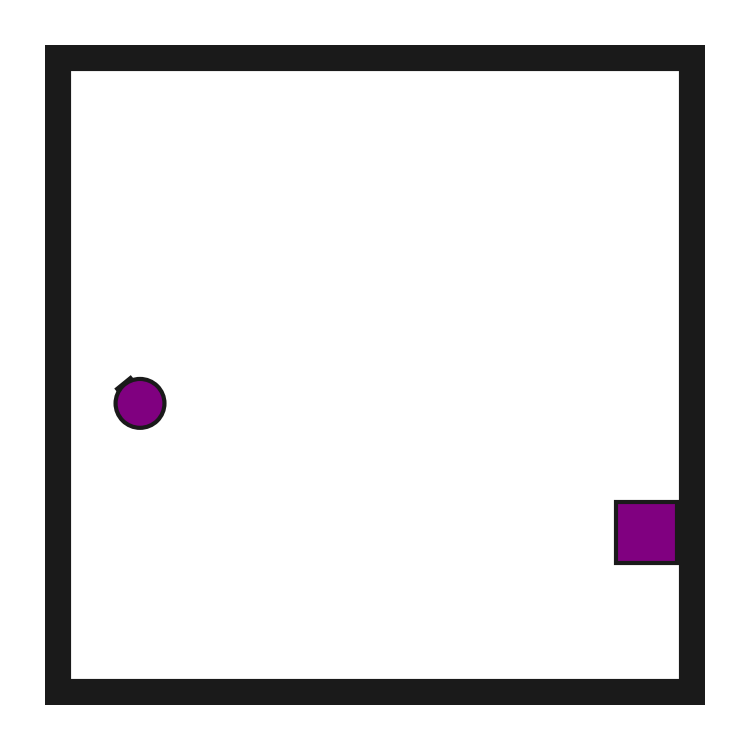

In [10]:
pil_frames = [PILImage.fromarray(f) for f in frames]
buf = BytesIO()
pil_frames[0].save(
    buf,
    format="GIF",
    save_all=True,
    append_images=pil_frames[1:],
    duration=100,
    loop=0,
)
Image(data=buf.getvalue(), format="gif")

## Cleanup

In [11]:
eval_env.close()
sim_env.close()